# $$\frac{dr}{dt} = \frac{k_1}{\sigma^2} U^T \frac{\partial f}{\partial x} (I - f(Ur)) + \frac{k_1}{\sigma_{td}^2} (r^{td} - r) - \frac{k_1}{2} g'(r)$$

### **The Variables**

- **$\frac{dr}{dt}$**: The rate of change of the neural activity (firing rate) over time.
    
- **$r$**: A vector representing the current firing rates of the neurons (also referred to as the network's internal estimate of the "causes" of the image).
    
- **$k_1$**: A positive rate constant that controls how fast the neurons update their firing rates (akin to a learning rate, but for neural activation rather than synaptic weights).
    
- **$\sigma^2$**: The variance of the noise in the bottom-up input. It dictates how much "trust" the network places in the raw sensory input.
    
- **$\sigma_{td}^2$**: The variance of the noise in the top-down prediction. It dictates how much "trust" the network places in the predictions coming from the higher cortical level.
    
- **$U$**: A matrix representing the feedforward synaptic weights of the neurons (or the "basis vectors" that encode features like oriented edges).
    
- **$U^T$**: The transpose of the synaptic weight matrix $U$. In the biological model, this represents the reciprocal feedback connections.
    
- **$I$**: The actual bottom-up input signal (e.g., the raw image patch or the activity from a lower cortical area).
    
- **$f$**: The neuronal activation function (typically a non-linear function like $tanh$, though the paper sometimes assumes a linear function where $f(x) = x$).
    
- **$x$**: A shorthand for $Ur$, the linear combination of the basis vectors.
    
- **$r^{td}$**: The "top-down" prediction of neural activity coming from the next higher level in the cortical hierarchy (e.g., V2 predicting V1).
    
- **$g(r)$**: A mathematical prior distribution applied to the neural activity. It acts as a regularization constraint.
    
- **$g'(r)$**: The derivative of that prior with respect to $r$.

# $$\frac{dU}{dt} = \frac{k_2}{\sigma^2} \frac{\partial f}{\partial x} (I - f(Ur)) r^T - k_2 \lambda U$$

### **The Variables**

- **$\frac{dU}{dt}$**: The rate of change of the synaptic weight matrix $U$ over time.
    
- **$k_2$**: A positive rate constant governing the learning rate for the synapses.
    
- **$r^T$**: The transpose of the neural activity vector. In a biological context, this represents the **presynaptic** activity.
    
- **$\lambda$**: A positive constant related to the variance of the prior distribution applied to the weights, acting as a weight decay parameter.
    

_(Note: $\sigma^2$, $\frac{\partial f}{\partial x}$, $I$, and $f(Ur)$ function exactly as they did in the state dynamics equation.)_

In [5]:
# Force quiet install of dependencies
!pip install -q mediapipe opencv-python-headless

# Download the specific Float16 Hand Landmarker task model
!wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [6]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from IPython.display import clear_output, display, HTML
import base64
import io
from PIL import Image

class PredictiveCodingLayer:
    def __init__(self, input_dim, hidden_dim, k1=0.8, k2=0.3, sigma2=1.0, sigma2_td=1.0, alpha=0.1, lam=0.02):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.k1 = k1
        self.k2 = k2
        self.sigma2 = sigma2
        self.sigma2_td = sigma2_td
        self.alpha = alpha
        self.lam = lam

        self.r = np.zeros((hidden_dim, 1))
        self.U = np.random.randn(input_dim, hidden_dim) * 0.1

    def get_prediction(self):
        return np.dot(self.U, self.r)

    def update_state(self, I, r_td, dt=0.1):
        if r_td is None: r_td = np.zeros_like(self.r)

        prediction = self.get_prediction()
        bottom_up_error = I - prediction
        top_down_error = r_td - self.r
        g_prime = 2 * self.alpha * self.r

        term1 = (self.k1 / self.sigma2) * np.dot(self.U.T, bottom_up_error)
        term2 = (self.k1 / self.sigma2_td) * top_down_error
        term3 = (self.k1 / 2) * g_prime

        dr_dt = term1 + term2 - term3
        self.r += dr_dt * dt
        return self.r, bottom_up_error

    def update_weights(self, I, dt=0.1):
        prediction = self.get_prediction()
        bottom_up_error = I - prediction

        hebbian_term = (self.k2 / self.sigma2) * np.dot(bottom_up_error, self.r.T)
        decay_term = self.k2 * self.lam * self.U

        dU_dt = hebbian_term - decay_term
        self.U += dU_dt * dt
        return self.U

NUM_LANDMARKS = 21
INPUT_DIM = NUM_LANDMARKS * 2

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (0, 17), (17, 18), (18, 19), (19, 20)
]

def draw_hand(frame, coords, color, offset_x=0):
    h, w, _ = frame.shape
    pts = []
    for i in range(NUM_LANDMARKS):
        x = int(coords[i*2] * w) + offset_x
        y = int(coords[i*2 + 1] * h)
        pts.append((x, y))
        cv2.circle(frame, (x, y), 4, color, -1)

    for (idx1, idx2) in HAND_CONNECTIONS:
        if pts[idx1] != (offset_x, 0) and pts[idx2] != (offset_x, 0):
            cv2.line(frame, pts[idx1], pts[idx2], color, 2)

In [7]:
def video_stream():
    js = """
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var pendingResolve = null;
    var shutdown = false;

    function onAnimationFrame() {
      if (!shutdown) window.requestAnimationFrame(onAnimationFrame);
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) return;
      div = document.createElement('div');
      document.body.appendChild(div);

      video = document.createElement('video');
      video.style.display = 'none'; // Hide raw feed, we will render via cv2_imshow
      video.width = 640;
      video.height = 480;
      video.autoplay = true;
      div.appendChild(video);

      stream = await navigator.mediaDevices.getUserMedia({video: { facingMode: 'user' }});
      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640;
      captureCanvas.height = 480;
      window.requestAnimationFrame(onAnimationFrame);
    }

    async function takePhoto() {
      if (shutdown) return "";
      if (div === null) await createDom();
      return new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
    }
    """
    display(HTML('<script>{}</script>'.format(js)))

def get_video_frame():
    js_reply = eval_js('takePhoto()')
    if not js_reply: return None
    image_bytes = base64.b64decode(js_reply.split(',')[1])
    img = Image.open(io.BytesIO(image_bytes))
    return np.array(img)

Active Inference Engine Online. Stop cell execution to halt.


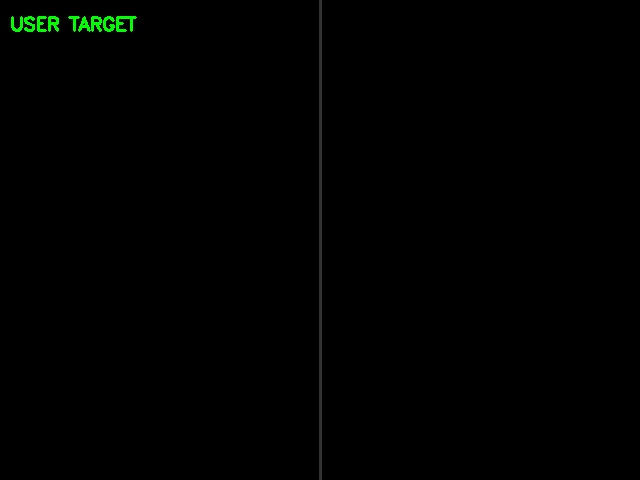

Inference Halted.


In [9]:
import time
from IPython.display import display, Image as IPyImage
import cv2
import numpy as np
import mediapipe as mp


base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.7,
    min_hand_presence_confidence=0.7,
    min_tracking_confidence=0.7
)
detector = vision.HandLandmarker.create_from_options(options)


hidden_dim = 16
pcn = PredictiveCodingLayer(INPUT_DIM, hidden_dim)
avatar_state = np.ones((INPUT_DIM, 1)) * 0.5
action_lr = 0.25


TRAINING_FRAMES = 150
current_frame = 0


video_stream()


time.sleep(2)

print("Active Inference Engine Online. Stop cell execution to halt.")


display_handle = display(display_id=True)

try:
    while True:

        img_array = get_video_frame()
        if img_array is None: break


        frame = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        detection_result = detector.detect(mp_image)

        display_frame = np.zeros_like(frame)
        h, w, _ = frame.shape
        half_w = w // 2

        if detection_result.hand_landmarks:
            hand_landmarks = detection_result.hand_landmarks[0]

            user_coords = []
            for lm in hand_landmarks:
                user_coords.extend([lm.x, lm.y])

            Y_user = np.array(user_coords).reshape(INPUT_DIM, 1)
            r_td = np.dot(pcn.U.T, Y_user)
            I_avatar = avatar_state


            if current_frame < TRAINING_FRAMES:
                # PHASE 1: PRE-TRAINING (Observation Only)

                for _ in range(3):
                    pcn.update_state(Y_user, r_td, dt=0.1)
                pcn.update_weights(Y_user, dt=0.1)

                cv2.putText(display_frame, f"TRAINING: WAVE HAND ({current_frame}/{TRAINING_FRAMES})", (half_w + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
                current_frame += 1
            else:
                # PHASE 2: ACTIVE INFERENCE

                for _ in range(3):
                    pcn.update_state(I_avatar, r_td, dt=0.1)
                pcn.update_weights(I_avatar, dt=0.1)

                prediction = pcn.get_prediction()
                avatar_state += action_lr * (prediction - avatar_state)

                cv2.putText(display_frame, "PCN AVATAR (ACTIVE)", (half_w + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)

            # --- UI Rendering ---
            scaled_user = Y_user.copy()
            for i in range(NUM_LANDMARKS): scaled_user[i*2] *= 0.5
            draw_hand(display_frame, scaled_user.flatten(), (0, 255, 0))

            scaled_avatar = avatar_state.copy()
            for i in range(NUM_LANDMARKS): scaled_avatar[i*2] *= 0.5
            draw_hand(display_frame, scaled_avatar.flatten(), (0, 165, 255), offset_x=half_w)

        cv2.putText(display_frame, "USER TARGET", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.line(display_frame, (half_w, 0), (half_w, h), (50, 50, 50), 2)


        _, jpeg = cv2.imencode('.jpg', display_frame)
        display_handle.update(IPyImage(data=jpeg.tobytes()))

except KeyboardInterrupt:
    print("Inference Halted.")
    eval_js('shutdown = true; if(stream) stream.getTracks().forEach(track => track.stop());')